In [1]:
# project 1st file 기본 전처리 후 모델 돌려보기 2025.11.26
import sys

project_root = 'c:/big20/git/big20-ML-project2-team3/CreditCardFraud'

# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import importlib
from utils import preprocessing
importlib.reload(preprocessing)
from matplotlib import rc


import utils.preprocessing as pp 
import utils.data_sampling as ds 
import utils.user_utils    as uu 
import utils.modeling      as mo

In [3]:
# data loading
df = pp.ccf_load_data()

데이터 로드 성공: (284807, 31)


In [4]:
# 기본정보 확인
pp.checkBasicInfo(df, isInfo=False, isGraph=False)


 결측치 정보 ======================================================================
✅ 결측치 없음

== 타겟 분포 ======================================================================

[Class] 개수:
Class
0    284315
1       492
Name: count, dtype: int64

[Class] 비율(%):
  Class 0: 99.83%
  Class 1: 0.17%
  ⚠️ 심각한 불균형 (0.17%)




In [5]:
# df_sacled.head()
## 데이터 
X_features, y_target = pp.split_features_target(df,cols='Time')
X_train, X_test, y_train, y_test = pp.data_split(X_features, y_target)

In [6]:
X_over, y_over = ds.oversampling_smote(X_train, y_train)
print(f'Before : {len(y_train)}, After: {len(y_over)}')
print(y_over.value_counts())

✅ SMOTE 오버샘플링 완료
   원본 샘플 수: 227845 (Class 0: 227451, Class 1: 394)
   샘플링 후: 454902 (Class 0: 227451, Class 1: 227451)
Before : 227845, After: 454902
Class
0    227451
1    227451
Name: count, dtype: int64


In [7]:
X_under, y_under = ds.undersampling_RUS(X_train, y_train)
print(f'Before : {len(y_train)}, After: {len(y_under)}')
print(y_under.value_counts())

✅ 랜덤 언더샘플링 완료
   원본 샘플 수: 227845 (Class 0: 227451, Class 1: 394)
   샘플링 후: 788 (Class 0: 394, Class 1: 394)
   제거된 샘플: 227057개
Before : 227845, After: 788
Class
0    394
1    394
Name: count, dtype: int64


In [8]:
X_combined, y_combined = ds.combined_sampling(X_train, y_train)

✅ SMOTETomek 혼합 샘플링 완료
   원본 샘플 수: 227845 (Class 0: 227451, Class 1: 394)
   샘플링 후: 454902 (Class 0: 227451, Class 1: 227451)
   최종 변화: +227057개


In [9]:
from sklearn.linear_model import LogisticRegression

results_dict = {}

model_name = 'LogisticRegression_notscaled_Timedrop_2025_11_26'

lr_best_params = {
    "random_state": 23,
    'C': 0.029, 
    'max_iter': 1000, 
    'penalty': 'l2', 
    'solver': 'lbfgs',
    'class_weight': 'balanced', 
    "n_jobs": -1     
}
lr_clf = LogisticRegression(**lr_best_params)

results_dict["origin"] = uu.get_model_train_eval(lr_clf, model_name, X_train, X_test, y_train, y_test)


✓ 모델 저장 완료: ../models\LogisticRegression_notscaled_Timedrop_2025_11_26.pkl
  파일 크기: 0.00 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
{'AUC': 0.9596, '정확도': 0.9757, '정밀도': 0.0589, '재현율': 0.8776, 'F1': 0.1105 }
{'오차행렬':
[[55491  1373]
 [   12    86]] }
실행 시간: 18.894750833511353


In [10]:
from sklearn.linear_model import LogisticRegression


model_name = 'LogisticRegression_notscaled_Timedrop_oversampled_2025_11_26'
lr_best_params = {
    "random_state": 23,
    'C': 0.029, 
    'max_iter': 1000, 
    'penalty': 'l2', 
    'solver': 'lbfgs',
    'class_weight': 'balanced', 
    "n_jobs": -1     
}

lr_clf = LogisticRegression(**lr_best_params)
results_dict["over"] = uu.get_model_train_eval(lr_clf, model_name, X_over, X_test, y_over, y_test)


✓ 모델 저장 완료: ../models\LogisticRegression_notscaled_Timedrop_oversampled_2025_11_26.pkl
  파일 크기: 0.00 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
{'AUC': 0.9575, '정확도': 0.9830, '정밀도': 0.0824, '재현율': 0.8776, 'F1': 0.1506 }
{'오차행렬':
[[55906   958]
 [   12    86]] }
실행 시간: 20.841952085494995


In [11]:


model_name = 'LogisticRegression_notscaled_Timedrop_undersampled_2025_11_26'

lr_clf = LogisticRegression(**lr_best_params)
results_dict["under"] = uu.get_model_train_eval(lr_clf, model_name, X_under, X_test, y_under, y_test)

✓ 모델 저장 완료: ../models\LogisticRegression_notscaled_Timedrop_undersampled_2025_11_26.pkl
  파일 크기: 0.00 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
{'AUC': 0.9689, '정확도': 0.9836, '정밀도': 0.0853, '재현율': 0.8776, 'F1': 0.1555 }
{'오차행렬':
[[55942   922]
 [   12    86]] }
실행 시간: 2.105647087097168


In [12]:

model_name = 'LogisticRegression_notscaled_Timedrop_combined_2025_11_26'

lr_clf = LogisticRegression(**lr_best_params)
results_dict['combine'] = uu.get_model_train_eval(lr_clf, model_name, X_combined, X_test, y_combined, y_test)

✓ 모델 저장 완료: ../models\LogisticRegression_notscaled_Timedrop_combined_2025_11_26.pkl
  파일 크기: 0.00 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
{'AUC': 0.9575, '정확도': 0.9830, '정밀도': 0.0824, '재현율': 0.8776, 'F1': 0.1506 }
{'오차행렬':
[[55906   958]
 [   12    86]] }
실행 시간: 20.550944566726685


📁 그래프 저장 완료: ..\images\샘플링 평가 지표 비표_2025_1128.png


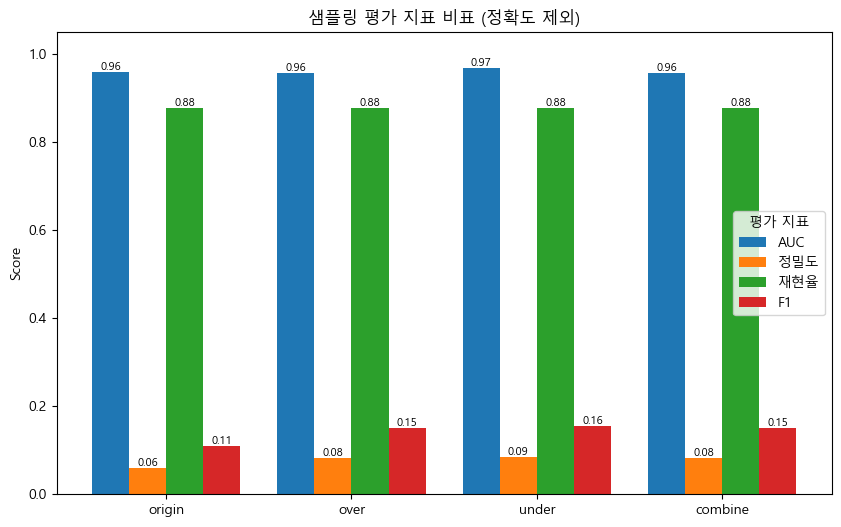

In [13]:
mo.plot_sampling_metrics(results_dict,title='샘플링 평가 지표 비표')


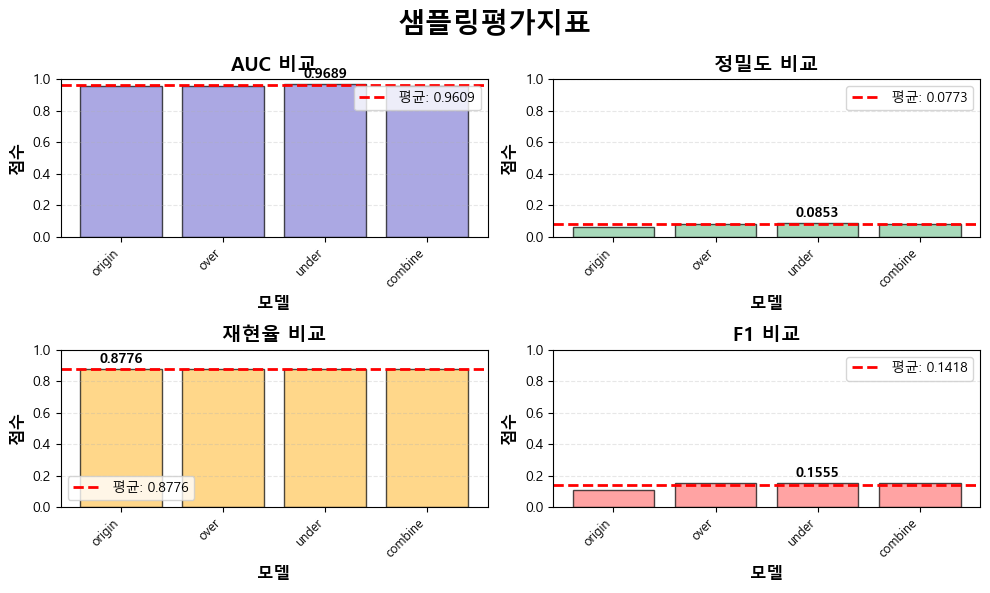


=== 지표별 통계 요약 ===

[AUC]
  최고: 0.9689 (under)
  최저: 0.9575 (over)
  평균: 0.9609
  표준편차: 0.0054

[정밀도]
  최고: 0.0853 (under)
  최저: 0.0589 (origin)
  평균: 0.0773
  표준편차: 0.0123

[재현율]
  최고: 0.8776 (origin)
  최저: 0.8776 (origin)
  평균: 0.8776
  표준편차: 0.0000

[F1]
  최고: 0.1555 (under)
  최저: 0.1105 (origin)
  평균: 0.1418
  표준편차: 0.0210


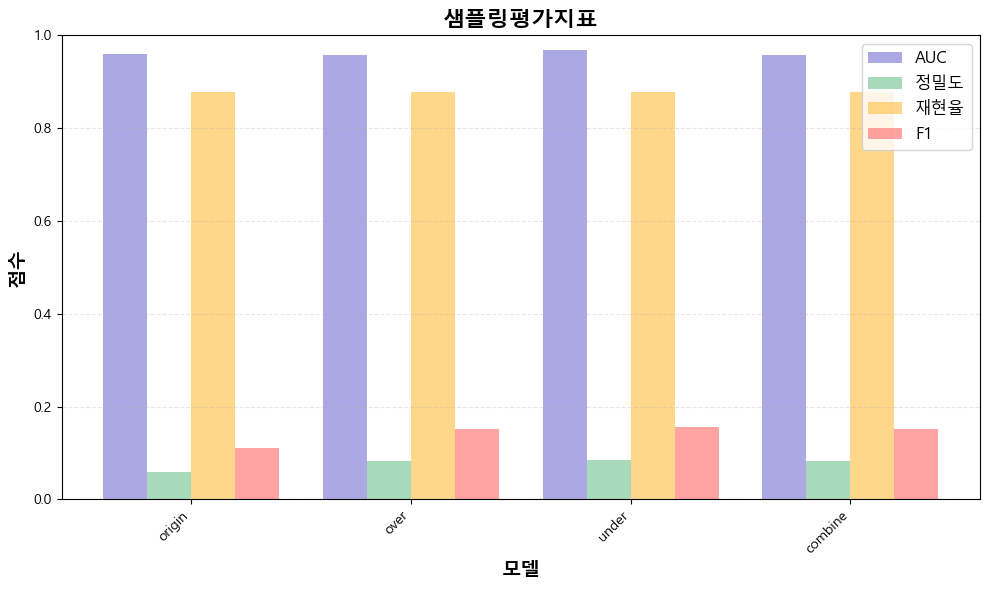


=== F1 Score 기준 상위 5개 모델 ===
            AUC     정밀도     재현율      F1
under    0.9689  0.0853  0.8776  0.1555
over     0.9575  0.0824  0.8776  0.1506
combine  0.9575  0.0824  0.8776  0.1506
origin   0.9596  0.0589  0.8776  0.1105

그래프가 저장되었습니다: ../images/샘플링평가지표_2025_1128.png


In [14]:
mo.model_metrics_graph(results_dict, title='샘플링평가지표',figsize=(10,6))